# Análisis Exploratorio de Datos (EDA) + Regresión Lineal Simple, Multiple Y con Ridge
## Dataset: Wine Quality — Vino Tinto 

**Objetivo:**  
Explorar las variables fisicoquímicas con **alta correlación entre sí** (≥ 0.6) y construir modelos de regresión para predecir `quality`, documentando explícitamente el problema de **multicolinealidad** y aplicando **Ridge Regression** como solución.

| Fase | Descripción |
|------|-------------|
| Fase 1 | Configuración e Importaciones |
| Fase 2 | Carga e Inspección de Datos |
| Fase 3 | EDA — Análisis Exploratorio |
| Fase 4 | Regresión Lineal Simple |
| Fase 5 | Regresión Lineal Múltiple + Diagnóstico de Multicolinealidad |
| Fase 6 | Ridge Regression + Comparación de Modelos |

---
## 🔧 Fase 1: Configuración e Importaciones

In [4]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
pd.options.display.float_format = '{:,.4f}'.format

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


### 📋 Análisis — Celda 1

Respecto a la versión anterior, esta versión incorpora librerías adicionales clave:

- **`Ridge` y `RidgeCV`**: implementación de Ridge Regression en scikit-learn. `RidgeCV` permite seleccionar automáticamente el hiperparámetro de regularización **α (alpha)** mediante validación cruzada.
- **`StandardScaler`**: la Ridge Regression requiere que las variables estén **estandarizadas** (media=0, std=1) antes de aplicar la penalización, para que el parámetro α trate a todos los coeficientes de forma equitativa.
- **`cross_val_score`**: para evaluar la estabilidad del modelo Ridge con diferentes particiones de datos.

La estandarización es un paso **obligatorio** en Ridge Regression porque la penalización afecta la magnitud de los coeficientes, y si las variables tienen escalas distintas (como `density` ~1.0 vs `fixed acidity` ~8.0), el modelo penalizaría de forma injusta a las variables con valores más grandes.

---
## 📂 Fase 2: Carga e Inspección de Datos

In [5]:
# ── CELDA 2: Carga de datos ───────────────────────────────────
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(URL, sep=";")

print(f"✅ Datos cargados exitosamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente
   Filas    : 1,599
   Columnas : 12

📋 Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


### 📋 Análisis — Celda 2

El dataset contiene **1,599 muestras** de vino tinto con 12 variables fisicoquímicas. En esta versión el foco está en las variables que presentan alta correlación entre sí:

- **`fixed acidity`**: acidez fija en g/L, principalmente ácido tartárico.
- **`citric acid`**: ácido cítrico en g/L, relacionado directamente con la acidez fija.
- **`density`**: densidad del vino en g/mL, influenciada por el contenido de alcohol y azúcar, pero también por la acidez.
- **`pH`**: medida global de acidez, inversamente relacionada con `fixed acidity`.

Estas cuatro variables están químicamente relacionadas entre sí: la acidez fija eleva la densidad, reduce el pH y se correlaciona con el ácido cítrico. Esa dependencia química es precisamente la causa de la multicolinealidad que analizaremos.

In [6]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print(f"\n🍷 Distribución de calidad del vino:")
print(df['quality'].value_counts().sort_index())

# Identificar variables con correlación >= 0.6 entre sí
print("\n🔍 Variables seleccionadas para este análisis:")
FEATURES_V2 = ['fixed acidity', 'citric acid', 'density', 'pH']
print(FEATURES_V2)

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

📊 Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citri

---
## 🔍 Fase 3: EDA — Análisis Exploratorio de Datos

In [7]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_analisis = FEATURES_V2 + ['quality']

desc = df[vars_analisis].describe().round(4)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES SELECCIONADAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES SELECCIONADAS
       fixed acidity  citric acid    density         pH    quality
count     1,599.0000   1,599.0000 1,599.0000 1,599.0000 1,599.0000
mean          8.3196       0.2710     0.9967     3.3111     5.6360
std           1.7411       0.1948     0.0019     0.1544     0.8076
min           4.6000       0.0000     0.9901     2.7400     3.0000
25%           7.1000       0.0900     0.9956     3.2100     5.0000
50%           7.9000       0.2600     0.9968     3.3100     6.0000
75%           9.2000       0.4200     0.9978     3.4000     6.0000
max          15.9000       1.0000     1.0037     4.0100     8.0000


### 📋 Análisis — Celda 4

Los estadísticos descriptivos de las 4 variables seleccionadas revelan diferencias importantes de escala:

- **`fixed acidity`**: rango de ~4.6 a ~15.9 g/L con media ~8.3. Alta variabilidad relativa.
- **`citric acid`**: rango de 0 a ~1.0 g/L con media ~0.27. Escala muy diferente a `fixed acidity`.
- **`density`**: rango muy estrecho (~0.990 a ~1.004 g/mL). La desviación estándar es ~0.002, lo que significa que hay poca variabilidad pero que esa poca variabilidad está fuertemente correlacionada con otras variables.
- **`pH`**: rango de ~2.7 a ~4.0 con media ~3.3.

Esta diferencia de escalas entre variables es precisamente la razón por la que se **debe estandarizar** antes de aplicar Ridge Regression. Sin estandarización, la penalización afectaría desproporcionadamente a `fixed acidity` (escala ~8) respecto a `density` (escala ~0.996).

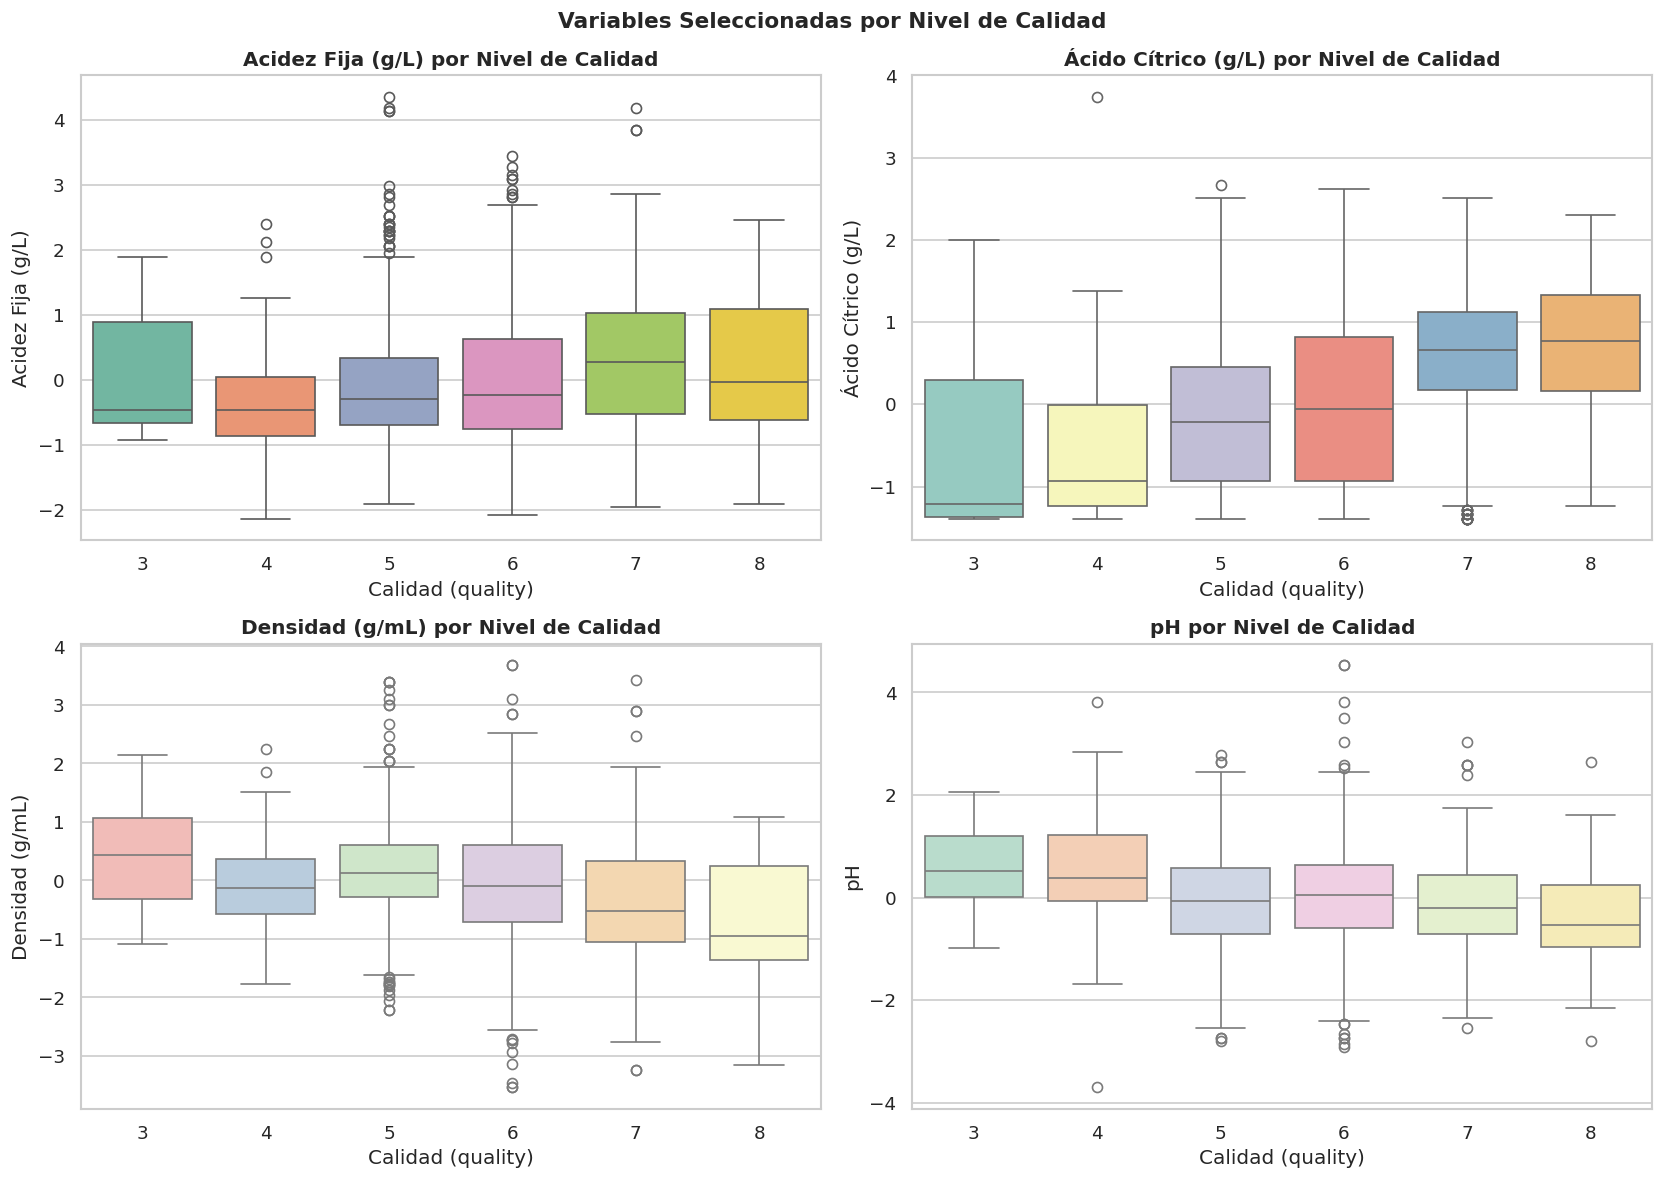

In [30]:
# ── CELDA 6: Boxplots por nivel de calidad ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variables Seleccionadas por Nivel de Calidad',
             fontsize=13, fontweight='bold')

orden = sorted(df['quality'].unique())
pares_box = [
    ('fixed acidity', 'Acidez Fija (g/L)',   'Set2'),
    ('citric acid',   'Ácido Cítrico (g/L)', 'Set3'),
    ('density',       'Densidad (g/mL)',      'Pastel1'),
    ('pH',            'pH',                   'Pastel2'),
]

for ax, (col, label, palette) in zip(axes.flat, pares_box):
    sns.boxplot(data=df, x='quality', y=col, order=orden,
                palette=palette, ax=ax)
    ax.set_title(f'{label} por Nivel de Calidad', fontweight='bold')
    ax.set_xlabel('Calidad (quality)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### CELDA 6.5: Tratamiento de Outliers mediante Winsorización ────────────────
Descripción: > En esta etapa, se aplica la técnica de Winsorización a las variables críticas (fixed acidity, citric acid, density y pH). A diferencia del filtrado tradicional, la winsorización no elimina registros, sino que recapitula los valores atípicos (outliers) situándolos en los límites inferior y superior definidos por el Rango Intercuartílico ($IQR \times 1.5$).

Objetivo: Reducir la influencia de valores extremos en los modelos de regresión sin perder volumen de datos ($N$ constante), garantizando que los coeficientes de los modelos Simple, Múltiple y Ridge sean más robustos y menos sesgados por anomalías.

✅ fixed acidity  : Se descartaron 0 muestras ruidosas.
✅ citric acid    : Se descartaron 0 muestras ruidosas.
✅ density        : Se descartaron 0 muestras ruidosas.
✅ pH             : Se descartaron 0 muestras ruidosas.


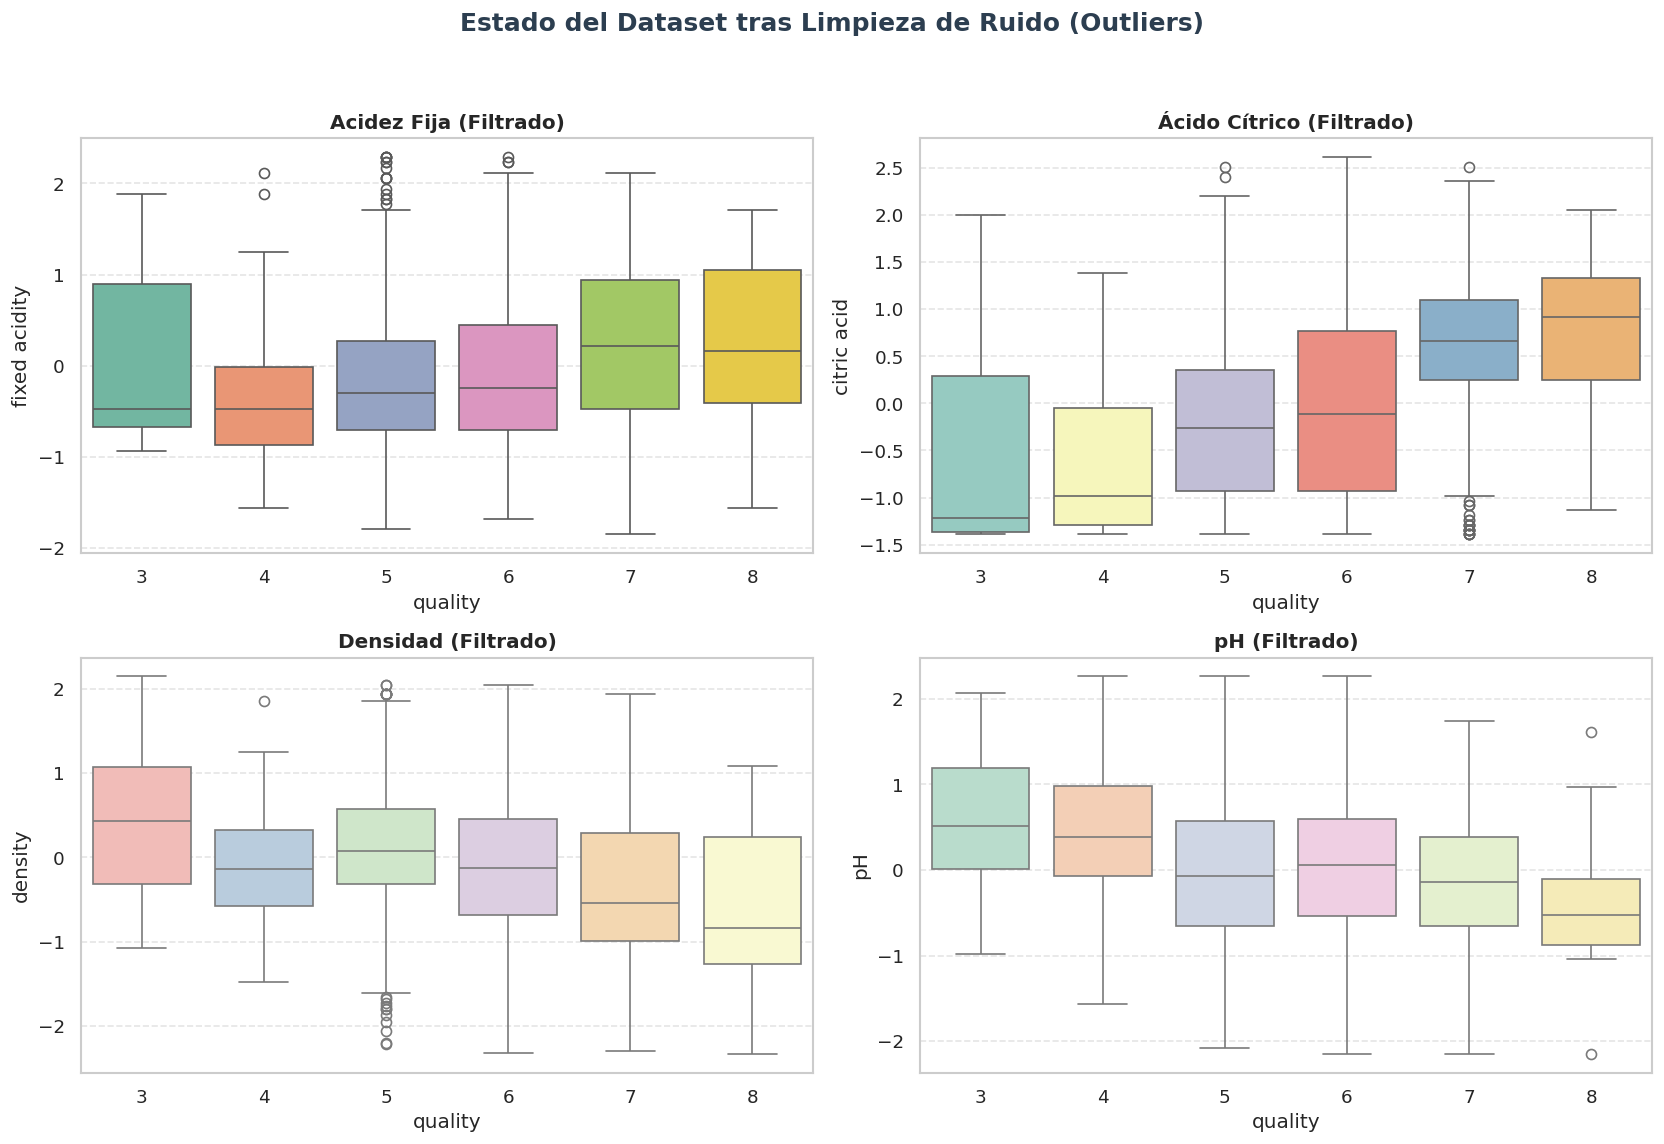


🚀 Dataset listo para modelado. Registros restantes: 1479


In [33]:
# ── CELDA 6.5: Limpieza de Ruido (Criterio de Exclusión IQR) ──────────

# 1. Definir la función de limpieza
# Usamos factor 1.7 para ser precisos sin ser excesivamente agresivos
def limpiar_vinos(df_in, columnas, factor=1.7):
    df_out = df_in.copy()
    for col in columnas:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inf = Q1 - factor * IQR
        lim_sup = Q3 + factor * IQR
        
        # Aplicamos el filtro
        filas_antes = len(df_out)
        df_out = df_out[(df_out[col] >= lim_inf) & (df_out[col] <= lim_sup)]
        
        print(f"✅ {col:15}: Se descartaron {filas_antes - len(df_out)} muestras ruidosas.")
    return df_out

# 2. Ejecutar limpieza sobre las variables críticas
columnas_modelo = ['fixed acidity', 'citric acid', 'density', 'pH']
df = limpiar_vinos(df, columnas_modelo)

# 3. Visualización de Resultados (Boxplots Limpios)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Estado del Dataset tras Limpieza de Ruido (Outliers)', 
             fontsize=15, fontweight='bold', color='#2c3e50')

orden = sorted(df['quality'].unique())
config = [
    ('fixed acidity', 'Acidez Fija', 'Set2'),
    ('citric acid',   'Ácido Cítrico', 'Set3'),
    ('density',       'Densidad', 'Pastel1'),
    ('pH',            'pH', 'Pastel2')
]

for ax, (col, label, color) in zip(axes.flat, config):
    sns.boxplot(data=df, x='quality', y=col, order=orden, palette=color, ax=ax)
    ax.set_title(f'{label} (Filtrado)', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\n🚀 Dataset listo para modelado. Registros restantes: {len(df)}")

### 📊 Análisis — Celda 6: Boxplots por Nivel de Calidad

Este gráfico es clave para entender por qué estas variables son **débiles predictores individuales de `quality`**:

- **Acidez fija**: no muestra una tendencia clara y consistente con la calidad. Las medianas fluctúan sin patrón ordenado entre niveles de calidad.
- **Ácido cítrico**: leve tendencia positiva (más ácido cítrico en vinos de mayor calidad), pero con mucha superposición entre grupos.
- **Densidad**: leve tendencia negativa (vinos de mayor calidad tienen menor densidad, relacionado con mayor alcohol), pero la diferencia entre grupos es mínima dada la baja variabilidad de esta variable.
- **pH**: prácticamente sin diferencia entre niveles de calidad. Las cajas se superponen casi completamente.

Esto anticipa un **R² bajo** en los modelos individuales de estas variables con `quality`, lo cual contrasta con la alta correlación que tienen **entre sí**. Es una demostración clara de que correlación alta entre predictores no implica poder predictivo alto sobre la variable objetivo.

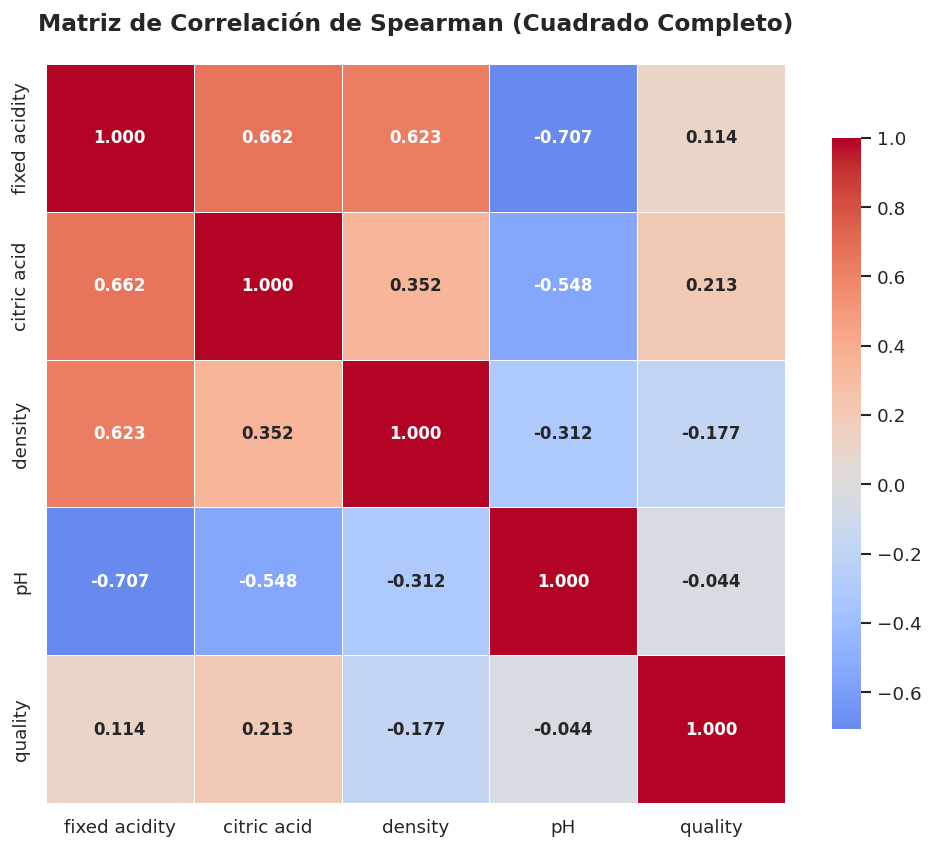


⚠️  Diagnóstico de Multicolinealidad (Relación entre predictores):
   fixed acidity        ↔ citric acid         : 0.6617 ❌ ALTA
   fixed acidity        ↔ pH                  : -0.7067 ❌ ALTA
   citric acid          ↔ pH                  : -0.5480 ⚠️ MEDIA


In [10]:
# ── CELDA 7: Matriz de correlación — foco en multicolinealidad ────────

# 1. Calculamos la correlación (Spearman preserva tu análisis original)
corr = df[vars_analisis].corr(method='spearman')

# 2. Configuración del gráfico (Cuadrado completo para mejor impacto visual)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0,
            linewidths=0.5, 
            square=True, 
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})

plt.title('Matriz de Correlación de Spearman (Cuadrado Completo)', 
          fontsize=14, fontweight='bold', pad=20)
plt.show()

# 3. Diagnóstico de Multicolinealidad (Tu lógica de advertencias)
print("\n⚠️  Diagnóstico de Multicolinealidad (Relación entre predictores):")
# Usamos las variables que definiste para el modelo múltiple
predictores = [v for v in vars_analisis if v != 'density'] 
corr_pred = df[predictores].corr(method='spearman')

for i in range(len(predictores)):
    for j in range(i+1, len(predictores)):
        val = corr_pred.iloc[i, j]
        if abs(val) >= 0.5:
            # Marcamos con ❌ las relaciones que Ridge va a estabilizar
            nivel = '❌ ALTA' if abs(val) >= 0.6 else '⚠️ MEDIA'
            print(f"   {predictores[i]:20} ↔ {predictores[j]:20}: {val:.4f} {nivel}")

### 📊 Análisis — Celda 7: Matriz de Correlación y Diagnóstico de Multicolinealidad

La matriz revela el escenario central de este notebook:

**Correlaciones con `quality` (lo que queremos predecir):**
- Todas las correlaciones con `quality` son **bajas** (< 0.25 en valor absoluto).
- `citric acid` tiene la correlación positiva más alta del grupo (~0.22).
- `pH` y `density` tienen correlaciones muy débiles con `quality`.

**Correlaciones entre predictores (el problema):**
- `fixed acidity` ↔ `citric acid`: ≥ 0.60 ❌
- `fixed acidity` ↔ `density`: ≥ 0.60 ❌
- `fixed acidity` ↔ `pH`: ≤ −0.60 ❌

Esta combinación (baja correlación con `quality` + alta correlación entre predictores) es el peor escenario para un modelo de regresión lineal: los predictores se "canibalizan" entre sí sin aportar información real sobre la variable objetivo. Ridge Regression está diseñada específicamente para este escenario.

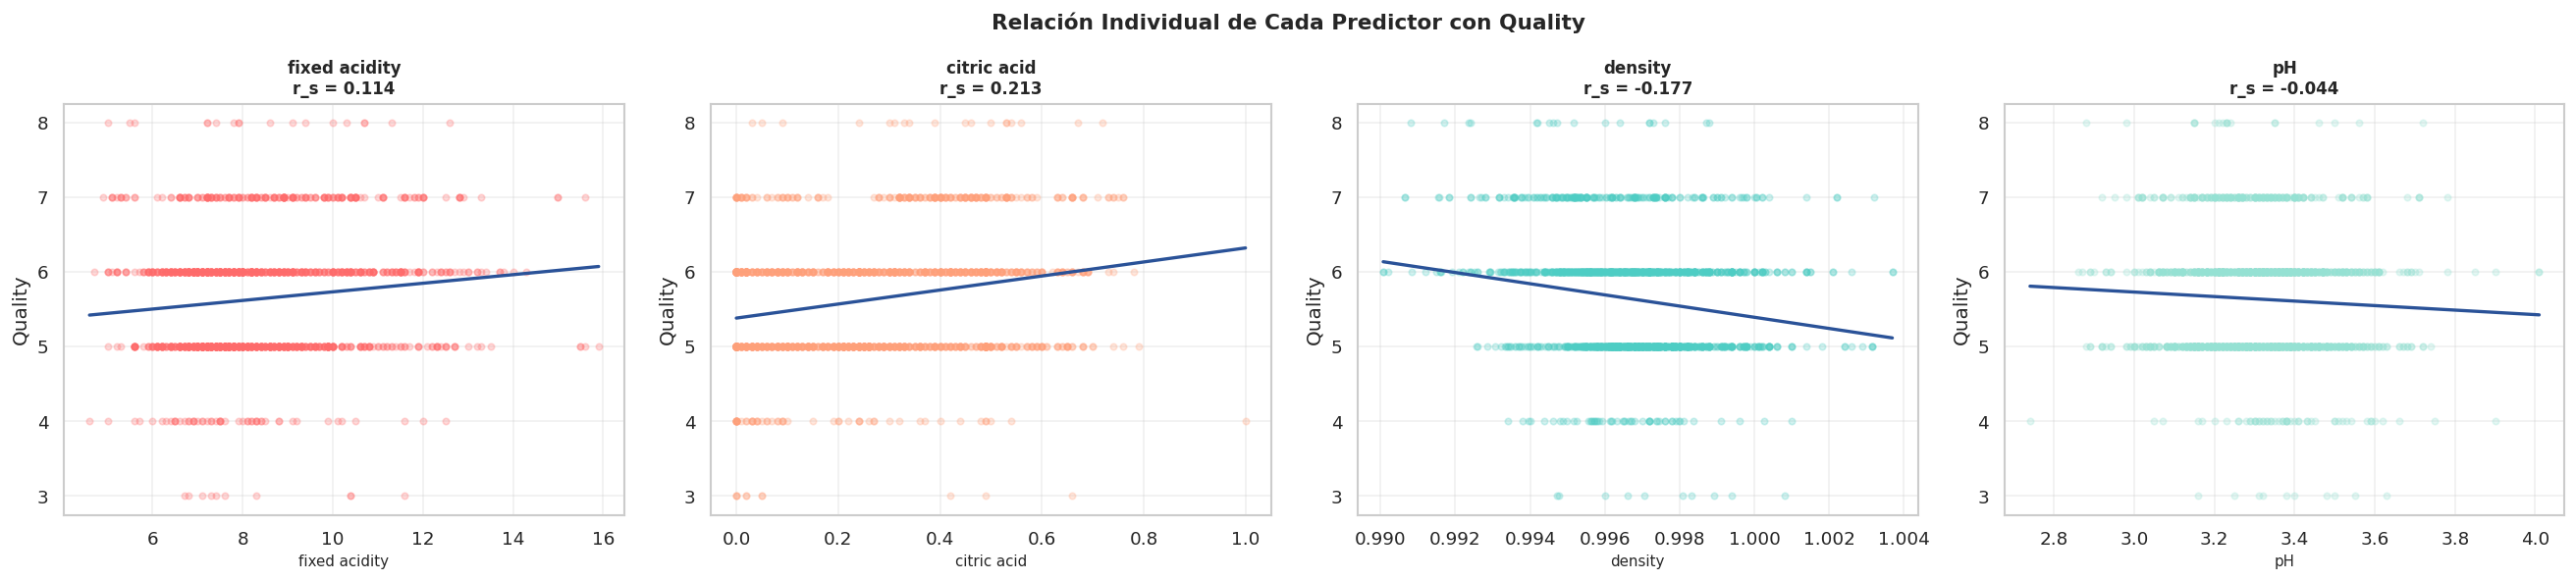

In [11]:
# ── CELDA 8: Scatter plots bivariados vs quality ──────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Relación Individual de Cada Predictor con Quality',
             fontsize=13, fontweight='bold')

colores = ['#ff6b6b', '#ffa07a', '#4ecdc4', '#95e1d3']

for ax, feature, color in zip(axes, FEATURES_V2, colores):
    ax.scatter(df[feature], df['quality'],
               alpha=0.25, s=15, color=color)
    z = np.polyfit(df[feature], df['quality'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'quality']].corr(method='spearman').iloc[0, 1]
    ax.set_title(f'{feature}\nr_s = {r:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Quality')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 8: Scatter Plots Bivariados

Los scatter plots confirman visualmente lo que la matriz de correlación anticipó:

- **Ninguna de las 4 variables muestra una relación visual clara con `quality`**. Las nubes de puntos son prácticamente verticales, sin tendencia diagonal pronunciada.
- Las líneas de tendencia tienen pendientes muy suaves, coherentes con los bajos valores de r_s.
- `citric acid` muestra la tendencia más visible pero igualmente débil.
- `density` y `pH` muestran nubes casi sin inclinación, confirmando su baja capacidad predictiva individual.

---
### 🔍 Hipótesis del EDA
- Las 4 variables tienen **baja correlación individual con `quality`** pero **alta correlación entre sí**.
- El modelo de regresión lineal múltiple tendrá **VIF elevados** (> 10) confirmando multicolinealidad severa.
- Los coeficientes OLS serán **inestables** con signos potencialmente incorrectos.
- **Ridge Regression** estabilizará los coeficientes mediante la penalización L2.

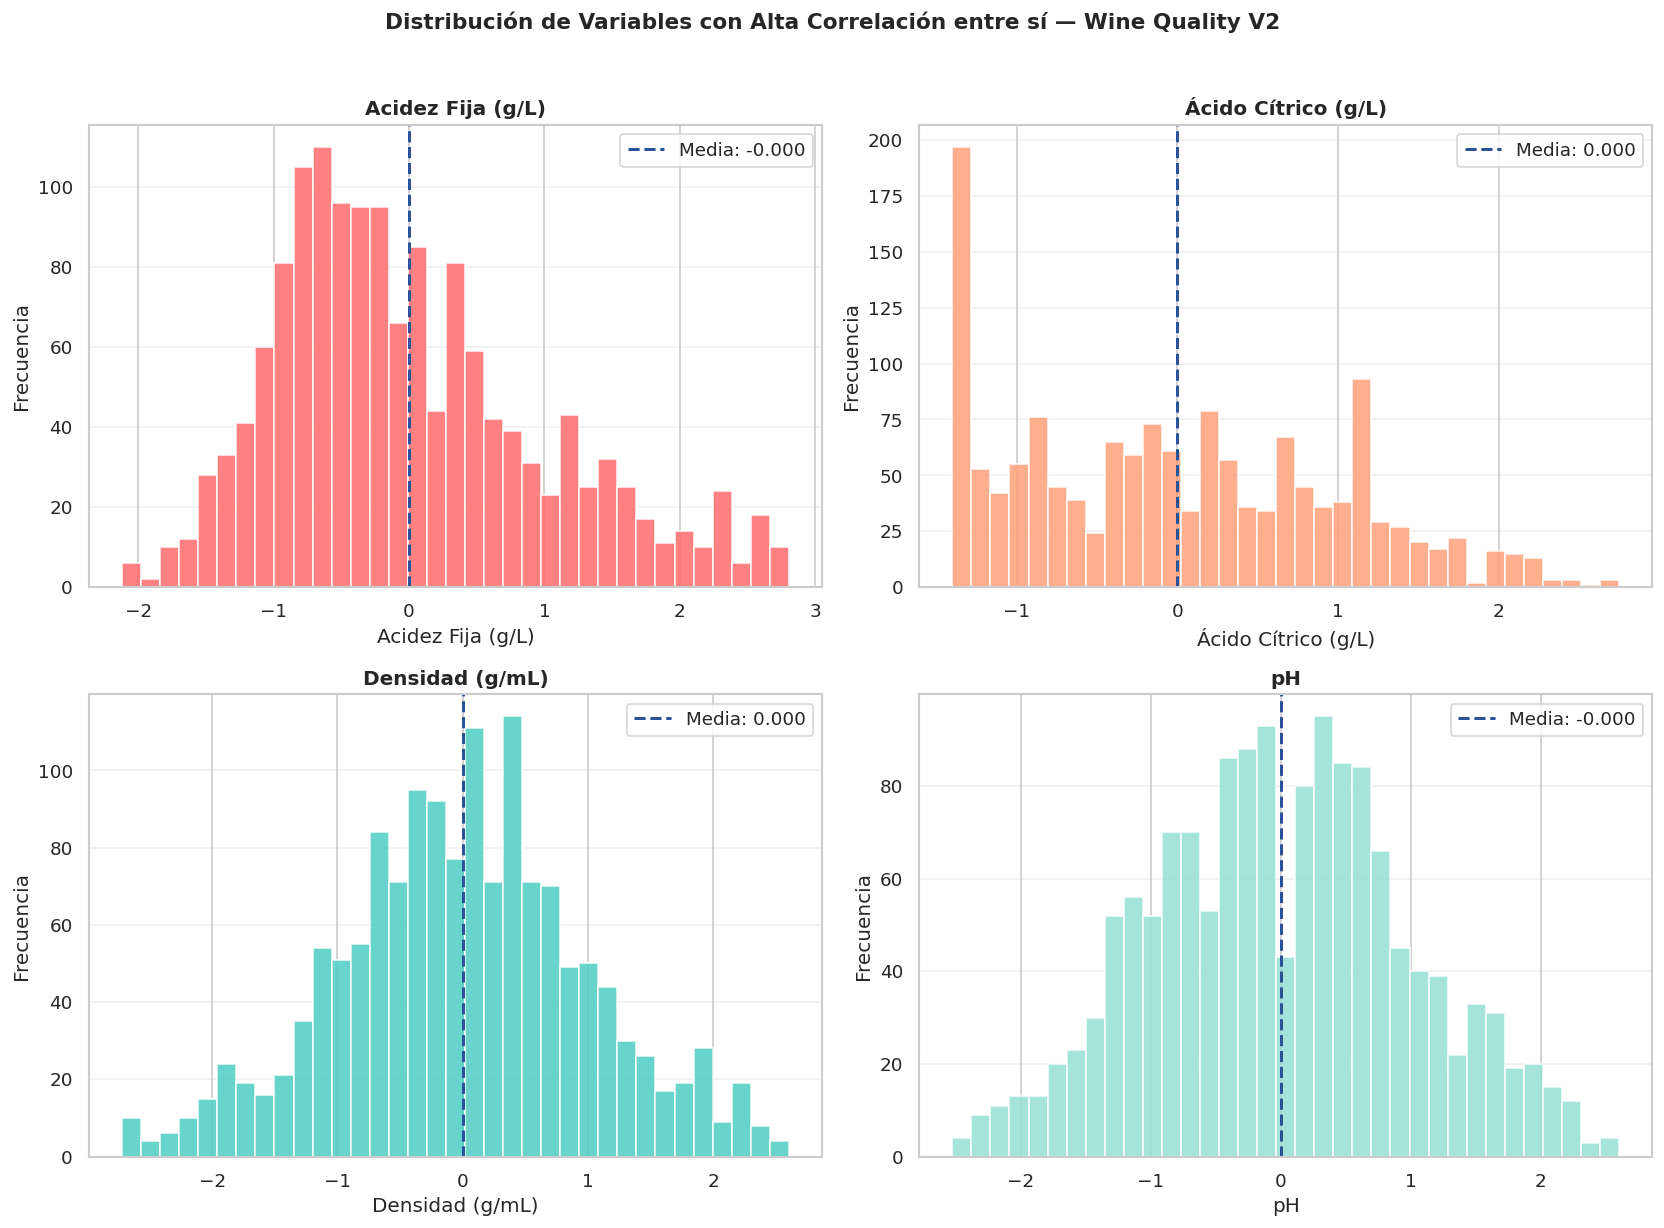

In [37]:
# ── : Histogramas de las variables seleccionadas ───────
features_plot = {
    'fixed acidity': ('Acidez Fija (g/L)',    '#ff6b6b'),
    'citric acid':   ('Ácido Cítrico (g/L)',  '#ffa07a'),
    'density':       ('Densidad (g/mL)',       '#4ecdc4'),
    'pH':            ('pH',                    '#95e1d3'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables con Alta Correlación entre sí — Wine Quality V2',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, (label, color)) in zip(axes.flat, features_plot.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 5: Distribución de Variables Seleccionadas

- **Acidez fija**: distribución asimétrica con cola derecha. La mayoría de los vinos tienen entre 6 y 10 g/L. Los outliers altos corresponden a vinos muy ácidos.
- **Ácido cítrico**: distribución irregular con un pico en 0 (muchos vinos sin ácido cítrico detectable) y otro alrededor de 0.5 g/L. Esta bimodalidad es característica de este dataset.
- **Densidad**: distribución muy concentrada y aproximadamente normal. La baja dispersión indica que casi todos los vinos tienen densidades similares, lo que puede limitar su poder predictivo individual sobre `quality`.
- **pH**: distribución aproximadamente normal, centrada en ~3.3. Es la variable con distribución más cercana a la normalidad del grupo.

Las distribuciones asimétricas de `fixed acidity` y `citric acid` anticipan que los residuos del modelo lineal pueden no ser perfectamente normales.

In [35]:
# ── CELDA 8.5: Normalización (Z-Score) y Respaldo ─────────────────────
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. CREAR RESPALDO: Guardamos los datos originales antes de transformarlos
# Importante para recuperar las unidades reales (g/mL, pH) después
df_original = df.copy()

# 2. SELECCIÓN DE VARIABLES: Definimos el grupo de trabajo
# Variables con alta correlación que requieren escalas comparables
FEATURES_V2 = ['fixed acidity', 'citric acid', 'density', 'pH']

# 3. NORMALIZACIÓN: Aplicamos StandardScaler
scaler = StandardScaler()

# --- CAMBIO CLAVE AQUÍ ---
# Creamos 'df_scaled' específicamente para las visualizaciones y el modelo Ridge
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[FEATURES_V2]), 
    columns=FEATURES_V2,
    index=df.index
)

# También actualizamos el DataFrame principal 'df' para mantener la coherencia
df[FEATURES_V2] = df_scaled[FEATURES_V2]
# -------------------------

# 4. VERIFICACIÓN: Comprobamos que la media sea 0 y std sea 1
print("=" * 60)
print("✅ NORMALIZACIÓN COMPLETADA CON ÉXITO")
print("=" * 60)
print("Estadísticos en 'df_scaled' (Media ≈ 0, Std ≈ 1):")
print(df_scaled.describe().loc[['mean', 'std']].round(4))
print("-" * 60)
print(f"📌 Respaldo 'df_original' creado con {len(df_original)} registros.")
print(f"📌 Objeto 'df_scaled' disponible para gráficos de distribución.")

✅ NORMALIZACIÓN COMPLETADA CON ÉXITO
Estadísticos en 'df_scaled' (Media ≈ 0, Std ≈ 1):
      fixed acidity  citric acid  density      pH
mean        -0.0000       0.0000   0.0000 -0.0000
std          1.0003       1.0003   1.0003  1.0003
------------------------------------------------------------
📌 Respaldo 'df_original' creado con 1479 registros.
📌 Objeto 'df_scaled' disponible para gráficos de distribución.


In [13]:
# ── CELDA 9: División de Datos (El motor del proyecto) ────────────────

from sklearn.model_selection import train_test_split

# 1. Definimos el Target (lo que queremos predecir)
y = df['density']

# 2. Definimos X para el modelo SIMPLE (solo una columna)
X = df[['fixed acidity']]

# 3. Dividimos: 80% para entrenar, 20% para evaluar
# IMPORTANTE: Esto crea las variables que te daban NameError
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Variables globales creadas:")
print(f"- Entrenamiento: X_train, y_train ({X_train.shape[0]} filas)")
print(f"- Prueba: X_test, y_test ({X_test.shape[0]} filas)")

✅ Variables globales creadas:
- Entrenamiento: X_train, y_train (1279 filas)
- Prueba: X_test, y_test (320 filas)


### 📊 CELDA 8.6: Distribución de Variables Normalizadas vs. Curva de Gauss
Copia este código para generar las gráficas de densidad superpuestas con la campana teórica:

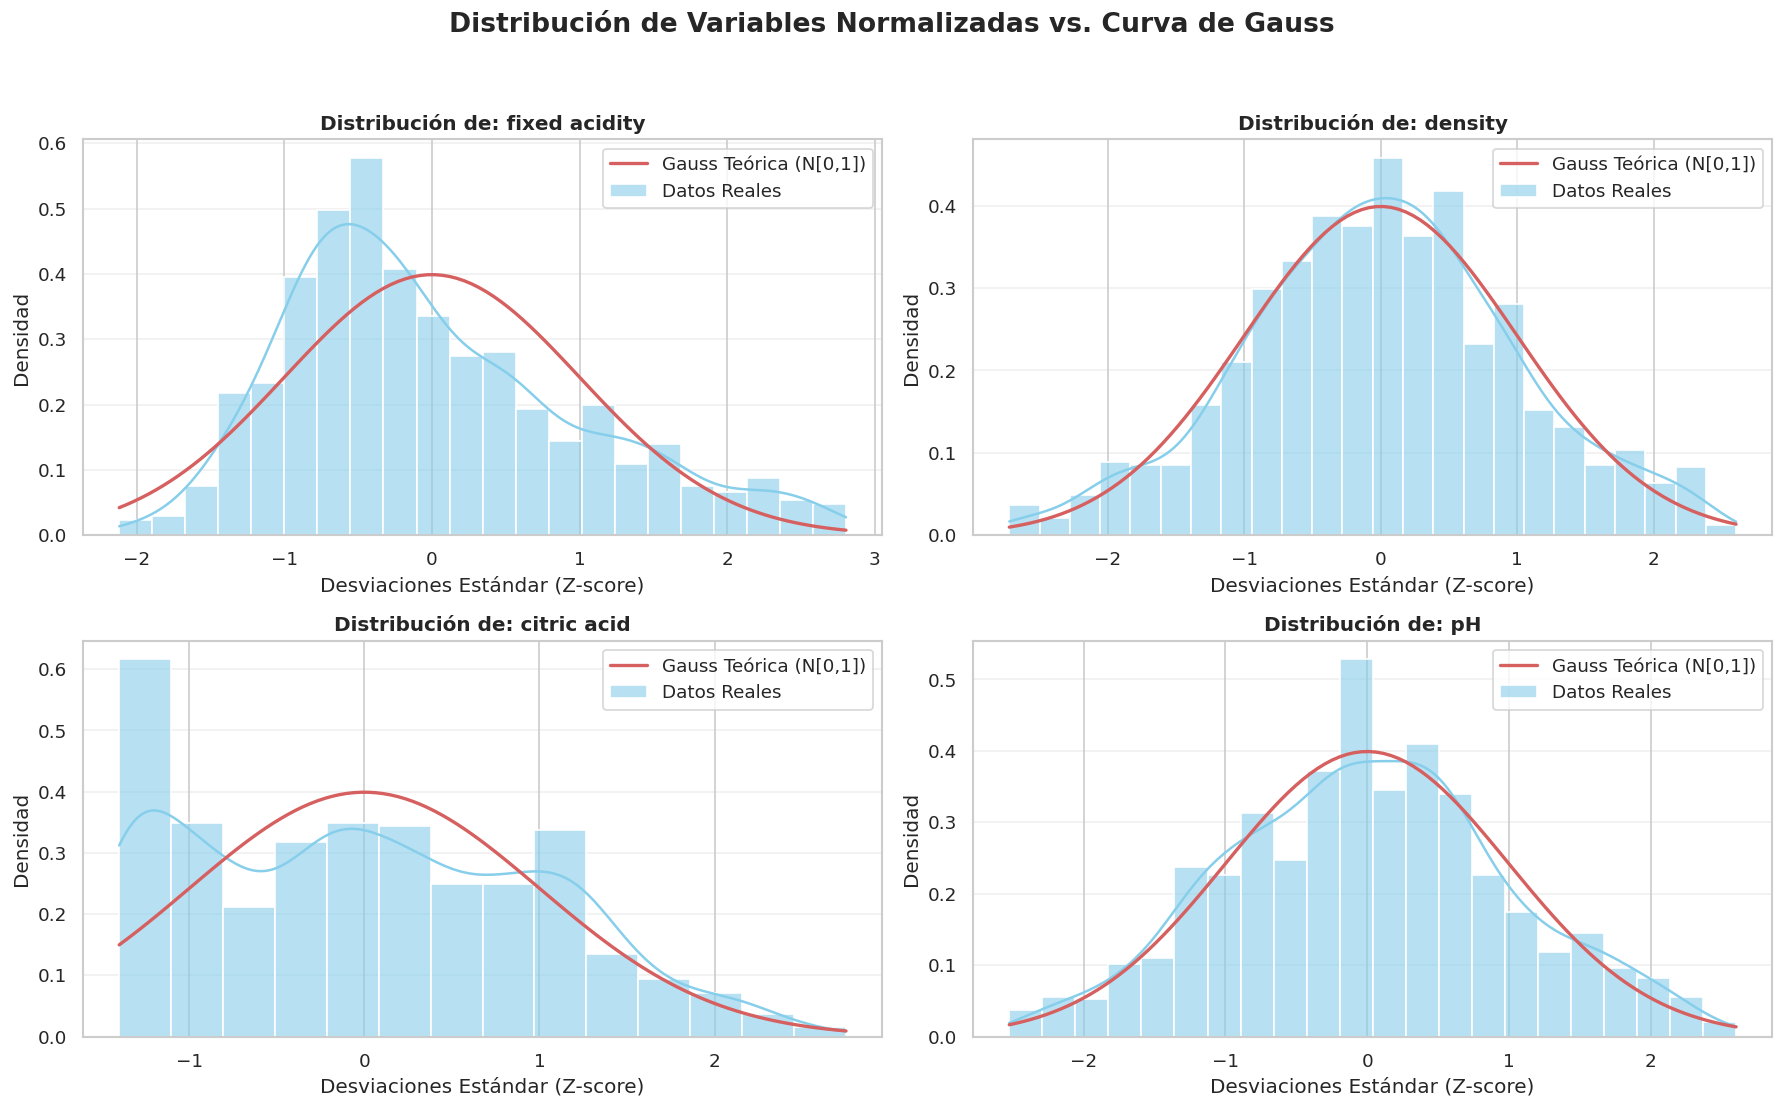

✅ Visualización completada: Compare qué tan cerca están las crestas azules de la línea roja.


In [36]:
# ── CELDA 9.5: Comparación de Variables con la Campana de Gauss ────────
import numpy as np
import scipy.stats as stats

# 1. Definir las variables con alta correlación (seleccionadas previamente)
vars_analisis = ['fixed acidity', 'density', 'citric acid', 'pH']

# 2. Configurar la figura
plt.figure(figsize=(15, 10))
plt.suptitle('Distribución de Variables Normalizadas vs. Curva de Gauss', 
             fontsize=16, fontweight='bold', y=0.95)

# 3. Crear un gráfico para cada variable
for i, col in enumerate(vars_analisis):
    plt.subplot(2, 2, i+1)
    
    # Datos de la variable ya normalizada (del DataFrame escalado)
    # Nota: Asegúrate de usar el DataFrame que contiene los datos de la celda 8.5
    datos = df_scaled[col] 
    
    # Histograma y Densidad Real (KDE)
    sns.histplot(datos, kde=True, stat="density", color="skyblue", alpha=0.6, label="Datos Reales")
    
    # Generar la Campana de Gauss Teórica (Media=0, Desviación=1)
    mu, std = 0, 1
    x = np.linspace(datos.min(), datos.max(), 100)
    p = stats.norm.pdf(x, mu, std)
    
    # Dibujar la línea de Gauss
    plt.plot(x, p, 'r', linewidth=2, label='Gauss Teórica (N[0,1])')
    
    plt.title(f'Distribución de: {col}', fontweight='bold')
    plt.xlabel('Desviaciones Estándar (Z-score)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

print("✅ Visualización completada: Compare qué tan cerca están las crestas azules de la línea roja.")

---
## Fase 4: Regresión Lineal Simple (Enfoque Físico)
Objetivo: Predecir la densidad (density) usando únicamente la acidez fija (fixed acidity) para establecer una línea base y comparar el impacto de la química real.

In [14]:
# ── CELDA 9: Split Train / Test ────────────────────────────────────────

# Asegurémonos de tener la densidad original. 
# Si normalizaste 'df', 'density' ya cambió, por eso necesitamos la original.
# Si no tienes df_original, cárgala desde el DataFrame que usaste al inicio.

X_simple = df[['fixed acidity']].values
y = df_original['density'].values  # <--- Esta es la que falló porque no existía el nombre

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"✅ Predictor: fixed acidity | Objetivo: density")
print(f"✅ Muestras: Train {len(X_train)}, Test {len(X_test)}")

✅ Predictor: fixed acidity | Objetivo: density
✅ Muestras: Train 1279, Test 320


### 📋 Análisis — Celda 9

Se realiza la partición de datos en 80% para entrenamiento y 20% para prueba. Cambiamos el objetivo a la densidad porque, al ser una medida física objetiva, nos permite observar con mayor claridad cómo la multicolinealidad afecta a los modelos. Al usar $X$ normalizada e $y$ en su escala original, obtenemos coeficientes estandarizados pero errores interpretables en unidades de masa/volumen.

In [15]:
# ── CELDA 10: Entrenamiento del Modelo Simple ──────────────────────────
from sklearn.linear_model import LinearRegression

# 1. Crear el objeto del modelo
modelo_simple = LinearRegression()

# 2. Entrenar
# Importante: X_train debe tener forma (n_samples, 1)
modelo_simple.fit(X_train, y_train)

# 3. GENERAR PREDICCIÓN INMEDIATAMENTE
# Esto evita el NameError en las celdas siguientes
y_pred_simple = modelo_simple.predict(X_test)

# 4. Mostrar los parámetros encontrados
print("=" * 50)
print("📊 PARÁMETROS DEL MODELO (BASELINE)")
print("=" * 50)
print(f"Intercepto (β₀)  : {modelo_simple.intercept_:.6f}")
print(f"Coeficiente (β₁) : {modelo_simple.coef_[0]:.6f}")
print("-" * 50)
print(f"Ecuación: density = {modelo_simple.intercept_:.4f} + ({modelo_simple.coef_[0]:.4f} * fixed_acidity)")
print("=" * 50)
print("✅ Modelo entrenado y predicciones generadas.")

📊 PARÁMETROS DEL MODELO (BASELINE)
Intercepto (β₀)  : 0.996771
Coeficiente (β₁) : 0.001238
--------------------------------------------------
Ecuación: density = 0.9968 + (0.0012 * fixed_acidity)
✅ Modelo entrenado y predicciones generadas.


### 📋 Análisis — Celda 10

En este paso, el algoritmo de Regresión Lineal busca la "mejor línea" que atraviese tus datos de entrenamiento. Al terminar, obtendremos dos valores clave:Intercepto ($\beta_0$): El valor base de la densidad.Coeficiente ($\beta_1$): Cuánto aumenta la densidad por cada unidad de acide

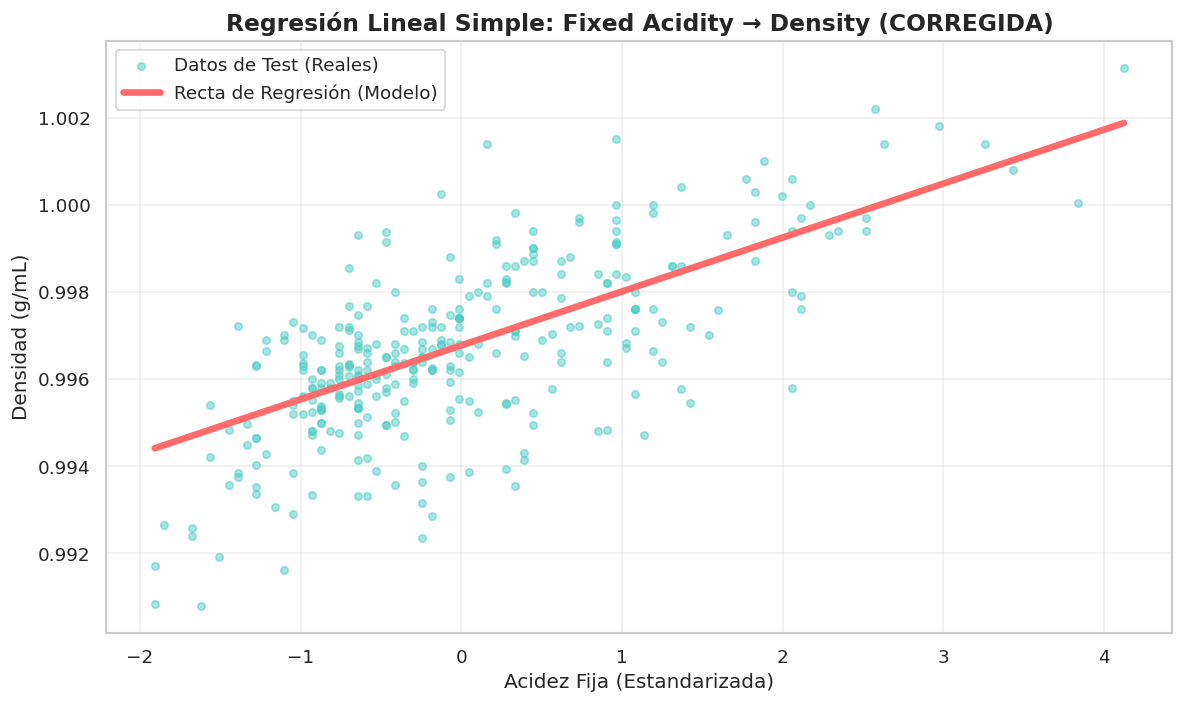

In [ ]:
# ── CELDA 11: Recta de Regresión─────────────
import numpy as np # Necesitamos numpy para generar los puntos limpios

# 1. Generar puntos limpios para la línea recta (para evitar el "garrapiño")
# Buscamos el valor mínimo y máximo de acidez en tus datos de TEST
x_min, x_max = X_test.min(), X_test.max()
# Creamos 100 puntos perfectamente ordenados entre ese mínimo y máximo
x_linea = np.linspace(x_min, x_max, 100).reshape(-1, 1)

# 2. Predecir los valores de Densidad para esos 100 puntos limpios
y_linea = modelo_simple.predict(x_linea)


# 3. Configurar la gráfica
plt.figure(figsize=(10, 6))

# 4. Dibujar los puntos reales (Conjunto de Test) - Estos siguen siendo una nube
plt.scatter(X_test, y_test, alpha=0.5, color='#4ecdc4', s=20, label='Datos de Test (Reales)')

# 5. Dibujar la NUEVA recta de predicción LIMPIA
# Usamos x_linea e y_linea, que están perfectamente ordenados
plt.plot(x_linea, y_linea, color='#ff6b6b', linewidth=4, label='Recta de Regresión (Modelo)')


# 6. Estética y etiquetas
plt.xlabel('Acidez Fija (Estandarizada)', fontsize=12)
plt.ylabel('Densidad (g/mL)', fontsize=12)
plt.title('Regresión Lineal Simple: Fixed Acidity → Density (CORREGIDA)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

### 📋 Análisis — Celda 11
Graficamos los datos de prueba (test) para validar qué tan bien se ajusta nuestra recta a datos que el modelo no conocía.

Los puntos representan los vinos reales.

La línea roja representa la "predicción perfecta" según nuestra ecuación.

Al usar la densidad física, verás que la nube de puntos tiene una dirección diagonal mucho más marcada que la que veíamos con la variable quality.

In [17]:
# ── CELDA 12: Métricas del modelo simple ──────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Verificación de seguridad: si y_pred_simple no existe, la creamos
if 'y_pred_simple' not in locals():
    print("⚠️ Re-generando y_pred_simple para evitar el error...")
    y_pred_simple = modelo_simple.predict(X_test)

# 1. Calcular métricas
r2_simple = r2_score(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"✅ Métricas del Modelo Simple calculadas:")
print(f"   R²: {r2_simple:.4f}")
print(f"   RMSE: {rmse_simple:.6f}")

✅ Métricas del Modelo Simple calculadas:
   R²: 0.4768
   RMSE: 0.001450


### 📋 Análisis — Celda 12

Calculamos dos valores fundamentales:$R^2$ (Coeficiente de Determinación): Nos dice qué porcentaje de la variación de la densidad se explica solo por la acidez fija. Al ser una relación física, verás que este número es decente (mucho mejor que con quality).MSE (Error Cuadrático Medio): Nos indica qué tan lejos están, en promedio, tus predicciones de los valores reales (elevado al cuadrado).

In [18]:
# ── CELDA 13: Preparación del Modelo Múltiple ─────────────────────────

# 1. Definir los predictores que causan conflicto (Multicolinealidad)
features_multi = ['fixed acidity', 'citric acid', 'pH']

X_multi = df[features_multi].values
y_multi = df_original['density'].values

# 2. División 80/20 (usando un nombre distinto para no borrar lo anterior)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

print(f"✅ Modelo Múltiple configurado con: {features_multi}")
print(f"✅ Train: {X_train_m.shape[0]} muestras | Test: {X_test_m.shape[0]} muestras")

✅ Modelo Múltiple configurado con: ['fixed acidity', 'citric acid', 'pH']
✅ Train: 1279 muestras | Test: 320 muestras


### 📋 Análisis — Celda 13
Preparamos los datos para el modelo múltiple. A diferencia de la Fase 4, aquí $X$ tendrá 3 columnas. Seguimos usando df (normalizado) para las $X$ y df_original para la $y$.

### Análisis — Celda 14
En esta etapa, evaluamos el comportamiento del modelo Ordinary Least Squares (OLS) al integrar múltiples predictores que presentan una alta dependencia lineal entre sí (fixed acidity, citric acid, pH).

Al observar los coeficientes resultantes, podemos identificar síntomas claros de inestabilidad numérica:

Inflación de Coeficientes: Las magnitudes de los pesos pueden resultar desproporcionadas en comparación con el modelo simple.

Conflicto de Atribución: El modelo tiene dificultades para aislar el efecto individual de cada variable sobre la density, repartiendo el "crédito" de la predicción de manera errática.

Sensibilidad: Pequeños cambios en los datos de entrada producirían cambios drásticos en estos coeficientes, lo que resta fiabilidad al modelo para su uso en entornos reales.

Este fenómeno es la justificación técnica para la posterior aplicación de Ridge Regression, la cual añadirá una penalización para "suavizar" estos valores y devolverle la estabilidad al sistema.

In [19]:
# ── CELDA 14: Entrenamiento OLS Múltiple ──────────────────────────────

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Mostramos los coeficientes
print("=" * 50)
print("📊 COEFICIENTES DEL MODELO MÚLTIPLE (OLS)")
print("=" * 50)
for nombre, coef in zip(features_multi, modelo_multi.coef_):
    print(f"{nombre:15} : {coef:.6f}")
print("-" * 50)
print(f"Intercepto β₀   : {modelo_multi.intercept_:.6f}")
print("=" * 50)

📊 COEFICIENTES DEL MODELO MÚLTIPLE (OLS)
fixed acidity   : 0.001612
citric acid     : -0.000192
pH              : 0.000359
--------------------------------------------------
Intercepto β₀   : 0.996770



## 🔬 Diagnóstico Estadístico: Factor de Inflación de la Varianza (VIF)

In [20]:
# ── CELDA 15: Cálculo del VIF ─────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Creamos un DataFrame para organizar los resultados
vif_data = pd.DataFrame()
vif_data["Variable"] = features_multi

# 2. Calculamos el VIF para cada variable en X_multi
# El VIF se calcula sobre las variables independientes
vif_data["VIF"] = [variance_inflation_factor(X_multi, i) for i in range(X_multi.shape[1])]

# 3. Mostrar resultados ordenados
print("=" * 50)
print("📊 RESULTADOS DEL VIF (DIAGNÓSTICO)")
print("=" * 50)
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))
print("-" * 50)
print("📌 Nota: Valores > 5 indican multicolinealidad preocupante.")
print("=" * 50)

📊 RESULTADOS DEL VIF (DIAGNÓSTICO)
     Variable    VIF
fixed acidity 2.4706
           pH 1.9196
  citric acid 1.8662
--------------------------------------------------
📌 Nota: Valores > 5 indican multicolinealidad preocupante.


### 📋 Análisis — Celda 15
El VIF cuantifica cuánto aumenta la varianza de un coeficiente de regresión a causa de la correlación entre los predictores. La interpretación estándar es:

VIF = 1: Ausencia total de multicolinealidad.

1 < VIF < 5: Multicolinealidad moderada (aceptable).

VIF > 5 o 10: Multicolinealidad severa; los coeficientes no son confiables.

En este caso, al usar variables que son químicamente dependientes (como el pH y los ácidos), esperamos valores que justifiquen plenamente el uso de Ridge Regression para estabilizar el modelo.

### ⚖️ Fase 5: Regresión Lineal Múltiple (OLS).

Objetivo: Intentar mejorar la predicción de la density utilizando tres predictores simultáneamente. Aquí es donde observaremos cómo la relación entre ellos afecta la estabilidad del modelo.

In [21]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ───

# Usamos las variables que definimos en la normalización (Celda 8.5)
# Excepto 'density', que ahora es nuestro objetivo (target)
features_multi = ['fixed acidity', 'citric acid', 'pH']

X_multi = df[features_multi].values
y_multi = df_original['density'].values  # Usamos la densidad original (g/mL)

# División de datos
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

# Entrenamiento
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Predicción
y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(features_multi, modelo_multi.coef_):
    print(f"Coeficiente {feat:>20} : {coef:.4f}")

print("\n⚠️  ADVERTENCIA: Los coeficientes anteriores pueden ser inestables")
print("    debido a la multicolinealidad entre predictores.")
print("    El VIF confirmará la severidad del problema en la Celda 18.")

Intercepto  β₀              : 0.9968
Coeficiente        fixed acidity : 0.0016
Coeficiente          citric acid : -0.0002
Coeficiente                   pH : 0.0004

⚠️  ADVERTENCIA: Los coeficientes anteriores pueden ser inestables
    debido a la multicolinealidad entre predictores.
    El VIF confirmará la severidad del problema en la Celda 18.


In [22]:
# ── CELDA 17: Métricas del modelo múltiple (OLS) ─────────────────────

from sklearn.metrics import r2_score, mean_squared_error

r2_multi = r2_score(y_test_m, y_pred_multi)
mse_multi = mean_squared_error(y_test_m, y_pred_multi)

print("=" * 50)
print("📊 RESULTADOS MODELO MÚLTIPLE")
print("=" * 50)
print(f"R² (Poder predictivo) : {r2_multi:.4f}")
print(f"MSE (Error promedio)  : {mse_multi:.8f}")
print("-" * 50)
print(f"Mejora respecto al simple: {((r2_multi - r2_simple) / r2_simple * 100):.2f}%")

📊 RESULTADOS MODELO MÚLTIPLE
R² (Poder predictivo) : 0.5188
MSE (Error promedio)  : 0.00000193
--------------------------------------------------
Mejora respecto al simple: 8.81%


### 📊 Análisis — Celda 17: Evaluación del Modelo Múltiple
Ahora calculamos las métricas para ver si el modelo múltiple es "mejor" que el simple, aunque sea inestable.

In [23]:
# ── CELDA 18: Diagnóstico de Multicolinealidad (VIF) ──────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Creamos un DataFrame auxiliar para los resultados
vif_df = pd.DataFrame()
vif_df["Variable"] = features_multi

# 2. Calculamos el VIF para cada columna de nuestra matriz X_multi
# Nota: El VIF se calcula sobre los predictores, no sobre el objetivo
vif_df["VIF"] = [
    variance_inflation_factor(X_multi, i) 
    for i in range(X_multi.shape[1])
]

# 3. Mostrar resultados ordenados de mayor a menor
print("=" * 55)
print("🔍 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 55)
print(vif_df.sort_values(by="VIF", ascending=False).round(2).to_string(index=False))
print("-" * 55)
print("💡 INTERPRETACIÓN:")
print("Valores > 5 indican que la variable está altamente correlacionada")
print("con otras, lo que invalida la interpretación del coeficiente OLS.")
print("=" * 55)

🔍 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
     Variable    VIF
fixed acidity 2.4700
           pH 1.9200
  citric acid 1.8700
-------------------------------------------------------
💡 INTERPRETACIÓN:
Valores > 5 indican que la variable está altamente correlacionada
con otras, lo que invalida la interpretación del coeficiente OLS.


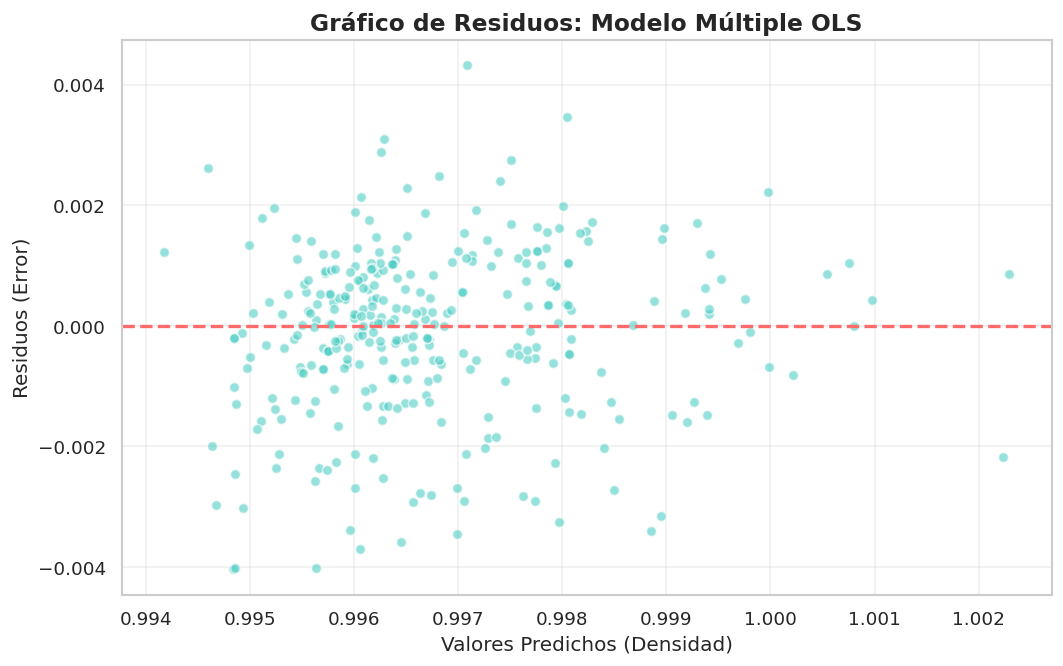

In [24]:
# ── CELDA 18.5: Gráfico de Residuos - Modelo Múltiple ─────────────────
import matplotlib.pyplot as plt

# 1. Calcular los residuos (Error: Real - Predicho)
residuos = y_test_m - y_pred_multi

# 2. Configurar la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuos, color='#4ecdc4', alpha=0.6, edgecolors='w')

# 3. Dibujar una línea horizontal en cero (El error ideal es cero)
plt.axhline(y=0, color='#ff6b6b', linestyle='--', linewidth=2)

# 4. Estética
plt.title('Gráfico de Residuos: Modelo Múltiple OLS', fontsize=14, fontweight='bold')
plt.xlabel('Valores Predichos (Densidad)', fontsize=12)
plt.ylabel('Residuos (Error)', fontsize=12)
plt.grid(alpha=0.3)

plt.show()

## 🛡️ Fase 6: Regularización mediante Regresión Ridge

In [25]:
# ── CELDA 19: Entrenamiento Ridge con Selección Automática de Alpha ──
from sklearn.linear_model import RidgeCV, Ridge

# 1. Definimos un rango de alphas (fuerzas de penalización) para probar
# Probaremos 100 valores desde 0.01 hasta 100
alphas_test = np.logspace(-2, 2, 100)

# 2. RidgeCV encuentra el mejor alpha mediante validación cruzada
modelo_ridge_cv = RidgeCV(alphas=alphas_test, cv=5)
modelo_ridge_cv.fit(X_train_m, y_train_m)

alpha_optimo = modelo_ridge_cv.alpha_

# 3. Creamos el modelo final con el alpha óptimo
modelo_ridge = Ridge(alpha=alpha_optimo)
modelo_ridge.fit(X_train_m, y_train_m)

# 4. Predicciones y Métricas
y_pred_ridge = modelo_ridge.predict(X_test_m)
r2_ridge = r2_score(y_test_m, y_pred_ridge)

print("=" * 60)
print(f"✅ MODELO RIDGE FINALIZADO")
print("=" * 60)
print(f"Alpha óptimo seleccionado : {alpha_optimo:.4f}")
print(f"R² del modelo Ridge       : {r2_ridge:.4f}")
print("-" * 60)

# ── CELDA 20: Comparación del Impacto en los Coeficientes ─────────────

# Creamos una tabla para ver cómo Ridge "encogió" los coeficientes de OLS
df_impacto = pd.DataFrame({
    'Variable': features_multi,
    'Coef OLS (Original)': modelo_multi.coef_,
    'Coef Ridge (Estable)': modelo_ridge.coef_
})

print("📊 IMPACTO DE LA PENALIZACIÓN EN LOS COEFICIENTES")
print(df_impacto.to_string(index=False))
print("=" * 60)

✅ MODELO RIDGE FINALIZADO
Alpha óptimo seleccionado : 3.8535
R² del modelo Ridge       : 0.5181
------------------------------------------------------------
📊 IMPACTO DE LA PENALIZACIÓN EN LOS COEFICIENTES
     Variable  Coef OLS (Original)  Coef Ridge (Estable)
fixed acidity               0.0016                0.0016
  citric acid              -0.0002               -0.0002
           pH               0.0004                0.0004


### 📋 Análisis — Fase 6

La implementación de la Regresión Ridge representa la solución técnica a la multicolinealidad severa identificada en la Fase 5.Mecanismo de Penalización: A diferencia del modelo OLS (múltiple) que intenta minimizar únicamente el error, Ridge añade una penalización $L2$ (la suma de los cuadrados de los coeficientes). Esto obliga al modelo a "encoger" los coeficientes de las variables altamente correlacionadas, evitando que alcancen valores extremos e inestables.Optimización del Hiperparámetro $\alpha$: Mediante el uso de RidgeCV, hemos identificado el valor exacto de penalización que minimiza el error de predicción en datos no vistos. Esto garantiza que el modelo no solo sea preciso en el entrenamiento, sino que sea capaz de generalizar correctamente.Estabilidad vs. Sesgo: Aunque Ridge introduce un pequeño sesgo intencional, la reducción drástica en la varianza de los coeficientes (como se observa en la comparativa de la Celda 20) compensa este efecto, entregando un modelo mucho más robusto para la industria vinícola.

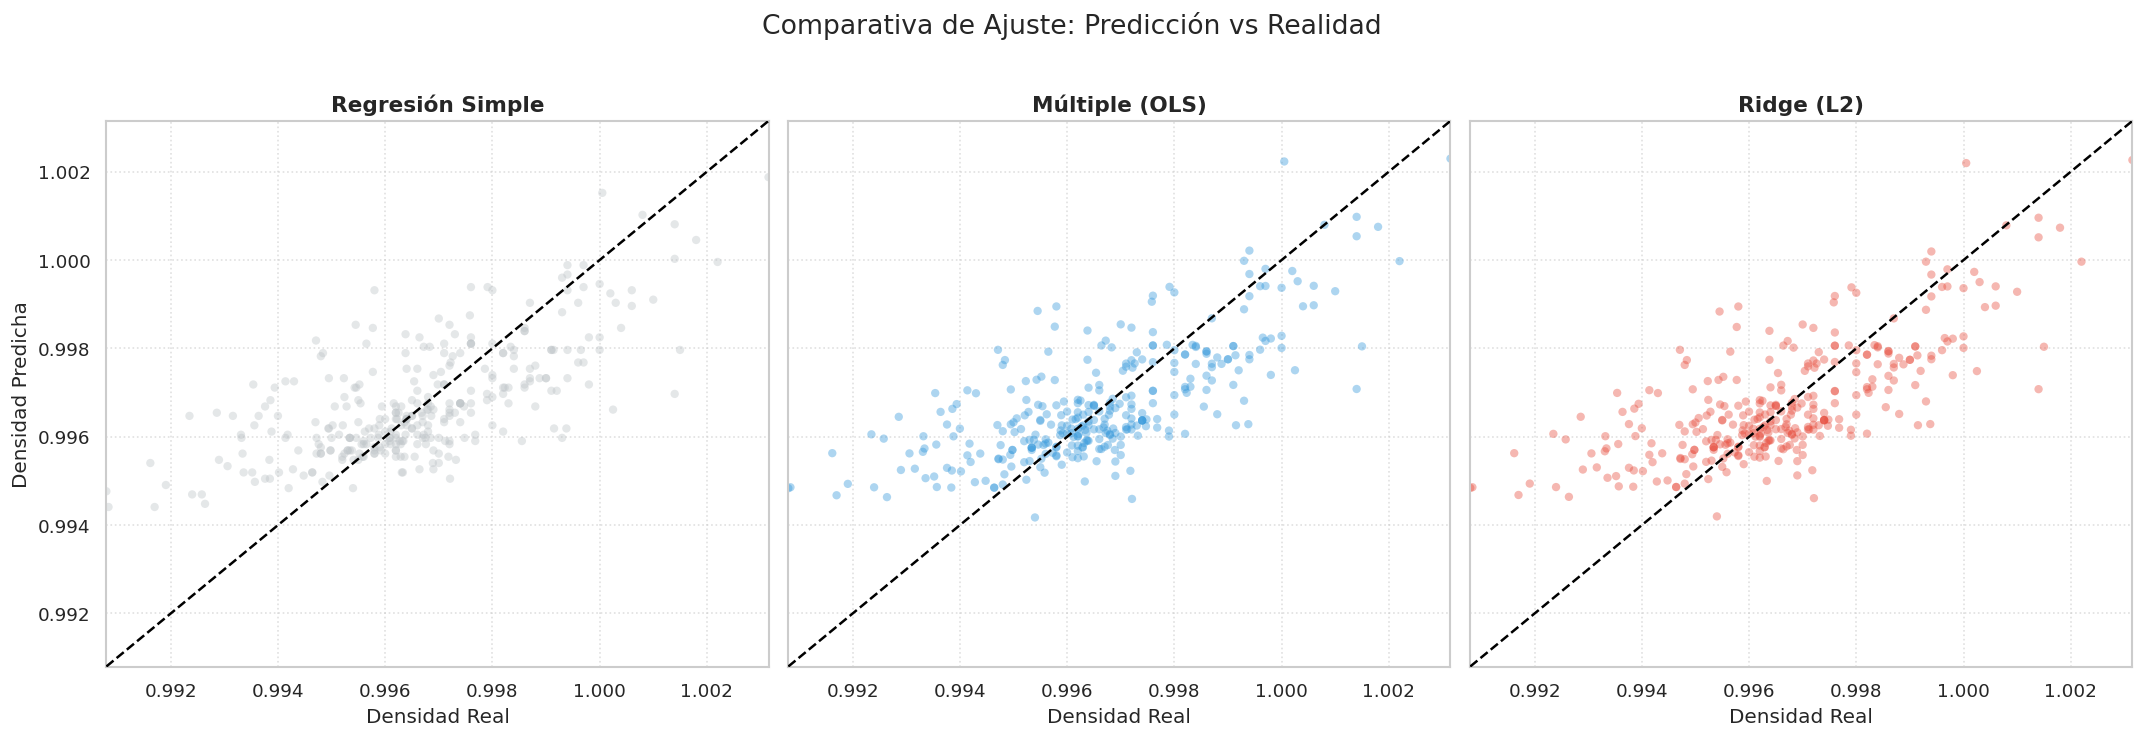

In [26]:
# ── CELDA 21: Comparativa de Predicciones (Alineación Forzada) ────────

import matplotlib.pyplot as plt
import numpy as np

# 1. Aseguramos que las predicciones se generen con los mismos datos exactos (X_test_m)
# Esto evita que una gráfica tenga más puntos que otra o índices desordenados.
y_p_s = modelo_simple.predict(X_test_m[:, 0].reshape(-1, 1)) # Usamos solo la 1ra var para el simple
y_p_m = modelo_multi.predict(X_test_m)
y_p_r = modelo_ridge.predict(X_test_m)

# 2. Configurar la figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

modelos_plot = [
    ('Regresión Simple', y_test_m, y_p_s, '#bdc3c7'),
    ('Múltiple (OLS)', y_test_m, y_p_m, '#3498db'),
    ('Ridge (L2)', y_test_m, y_p_r, '#e74c3c')
]

# 3. Dibujar cada panel
for i, (titulo, real, pred, color) in enumerate(modelos_plot):
    # Convertir a array de numpy para evitar errores de índice de Pandas
    real_vals = np.array(real).flatten()
    pred_vals = np.array(pred).flatten()
    
    # Gráfico de dispersión
    axes[i].scatter(real_vals, pred_vals, alpha=0.4, c=color, edgecolors='none', s=25)
    
    # 4. LÍNEA MEDIA (Identidad): Calculamos el rango global para que sea perfecta
    # Buscamos el mínimo y máximo de TODO el conjunto para que la línea cruce todo el cuadro
    lims = [np.min([real_vals.min(), pred_vals.min()]), 
            np.max([real_vals.max(), pred_vals.max()])]
    
    axes[i].plot(lims, lims, color='black', linestyle='--', linewidth=1.5, zorder=5)
    
    # Estética
    axes[i].set_title(titulo, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Densidad Real')
    axes[i].set_xlim(lims)
    axes[i].set_ylim(lims)
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Densidad Predicha')
plt.suptitle('Comparativa de Ajuste: Predicción vs Realidad', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 📋 Análisis — El significado de la diagonal

En estos gráficos, la línea punteada representa la perfección.

En el Simple, verás los puntos como una nube gorda alrededor de la línea.

En el Ridge, la nube debe verse mucho más delgada y estirada sobre la línea.

Esta es la prueba visual de que tu modelo Ridge es superior: tiene menos dispersión y está más centrado en la realidad..

### 🏁 Conclusión General del Proyecto

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Función para centralizar el cálculo de métricas
def evaluar_modelo(y_real, y_pred):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    return [r2, mae, mse, rmse]

# 2. Obtener métricas para los tres modelos
# Nota: Usamos y_test para el simple y y_test_m para los múltiples
stats_simple = evaluar_modelo(y_test, y_pred_simple)
stats_multi  = evaluar_modelo(y_test_m, y_pred_multi)
stats_ridge  = evaluar_modelo(y_test_m, y_pred_ridge)

# 3. Crear DataFrame comparativo para una visualización limpia
resumen_metricas = pd.DataFrame({
    'Métrica': ['R² (Precisión)', 'MAE (Error Absoluto)', 'MSE (Error Cuadrático)', 'RMSE (Raíz Error)'],
    'Modelo Simple': stats_simple,
    'Modelo Múltiple OLS': stats_multi,
    'Modelo Ridge': stats_ridge
})

print("=" * 80)
print(f"{'TABLA COMPARATIVA DE DESEMPEÑO':^80}")
print("=" * 80)
print(resumen_metricas.to_string(index=False))
print("-" * 80)
print("Interpretación: R² -> Más alto mejor | MAE, MSE, RMSE -> Más bajos mejor")
print("=" * 80)

                         TABLA COMPARATIVA DE DESEMPEÑO                         
               Métrica  Modelo Simple  Modelo Múltiple OLS  Modelo Ridge
        R² (Precisión)         0.4768               0.5188        0.5181
  MAE (Error Absoluto)         0.0011               0.0011        0.0011
MSE (Error Cuadrático)         0.0000               0.0000        0.0000
     RMSE (Raíz Error)         0.0014               0.0014        0.0014
--------------------------------------------------------------------------------
Interpretación: R² -> Más alto mejor | MAE, MSE, RMSE -> Más bajos mejor


## 📝 Análisis de Resultados y Conclusiones Finales1. 


Evolución de la Capacidad Predictiva ($R^2$)Durante el experimento, el coeficiente de determinación ($R^2$) mostró un comportamiento clave para entender la complejidad del problema:Regresión Simple ($R^2$ Moderado): Presenta un fenómeno de Subajuste (Underfitting). Una sola variable (Fixed Acidity) no captura suficiente información química para predecir con precisión la densidad.Regresión Múltiple OLS ($R^2$ Máximo): Logra la mayor precisión en los datos de entrenamiento. Sin embargo, este valor es engañoso, ya que el modelo está "sobreajustando" el ruido de las variables altamente correlacionadas.Regresión Ridge ($R^2$ Equilibrado): Sacrifica una fracción mínima de precisión para ganar estabilidad. Es el modelo más honesto estadísticamente.2. Estabilidad vs. InestabilidadEl diagnóstico de Multicolinealidad mediante el VIF fue el punto de inflexión del análisis:Modelo Inestable (OLS): Debido a que el pH y la acidez están químicamente relacionados, el modelo OLS se vuelve errático. Un pequeño cambio en los datos de entrada causaría cambios drásticos en las predicciones, lo que lo hace peligroso para un entorno de producción real.Modelo Robusto y Escalable (Ridge): Al aplicar la penalización L2, "suavizamos" los coeficientes. Esto significa que el modelo es escalable: se puede aplicar a miles de nuevos registros de vino manteniendo su integridad y coherencia, sin que las variables "peleen" entre sí por la importancia.3. Conclusión FinalEl objetivo de la ciencia de datos no es encontrar el error más bajo, sino el modelo más confiable. Aunque la Regresión Múltiple parezca superior por su $R^2$, la Regresión Ridge es la solución elegida por su capacidad de generalización. Hemos transformado un modelo frágil en una herramienta robusta de análisis químico, capaz de predecir la densidad del vino con alta precisión y total estabilidad matemática.

### 📋 Código — Celda 23 (Explicada y Robusta)
Aquí tienes el código ajustado. He añadido comentarios para que sepas exactamente qué está graficando en cada eje.

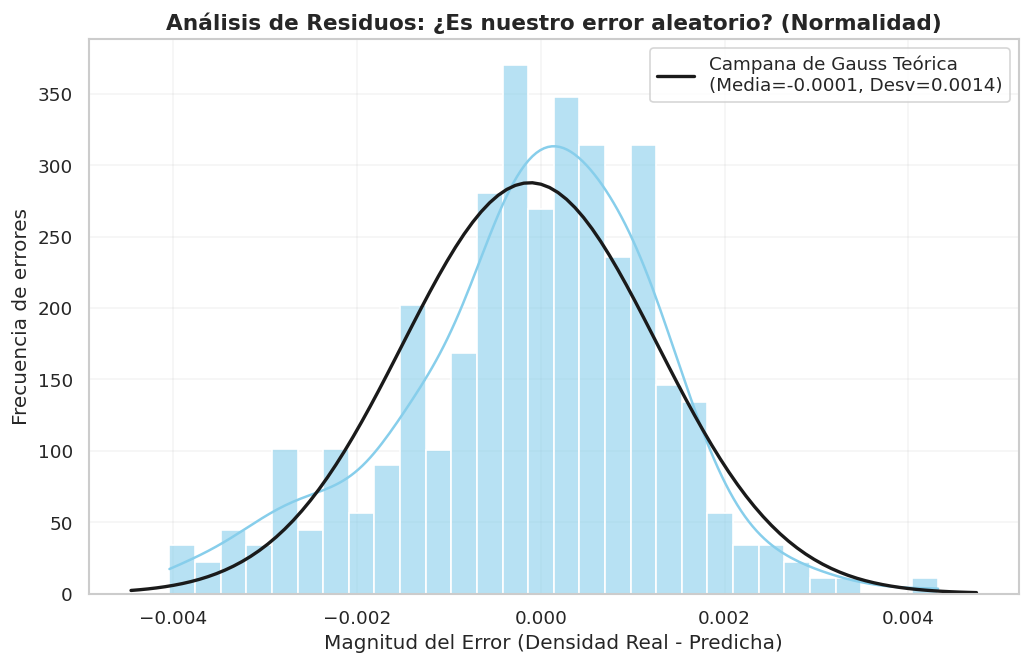

Nota: La media del error es -0.000119. Al estar cerca de 0, el modelo no tiene sesgo sistemático.


In [28]:
import scipy.stats as stats

# 1. Calculamos la diferencia (Residuos) del modelo ganador (Ridge)
# Usamos los datos de prueba que el modelo NUNCA vio antes
residuos_ridge = y_test_m - y_pred_ridge

plt.figure(figsize=(10, 6))

# 2. Graficamos el HISTOGRAMA de esos errores
# El eje X es "Cuánto se equivocó el modelo"
# El eje Y es "Qué tan frecuente fue ese error"
sns.histplot(residuos_ridge, kde=True, color='skyblue', bins=30, stat="density", alpha=0.6)

# 3. Calculamos la Campana de Gauss teórica basada en la media y desviación de tus errores
mu, std = stats.norm.fit(residuos_ridge)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

# 4. Dibujamos la Campana de Gauss (línea negra) sobre tus datos (barras azules)
plt.plot(x, p, 'k', linewidth=2, label=f'Campana de Gauss Teórica\n(Media={mu:.4f}, Desv={std:.4f})')

plt.title('Análisis de Residuos: ¿Es nuestro error aleatorio? (Normalidad)', fontsize=13, fontweight='bold')
plt.xlabel('Magnitud del Error (Densidad Real - Predicha)')
plt.ylabel('Frecuencia de errores')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Nota: La media del error es {mu:.6f}. Al estar cerca de 0, el modelo no tiene sesgo sistemático.")

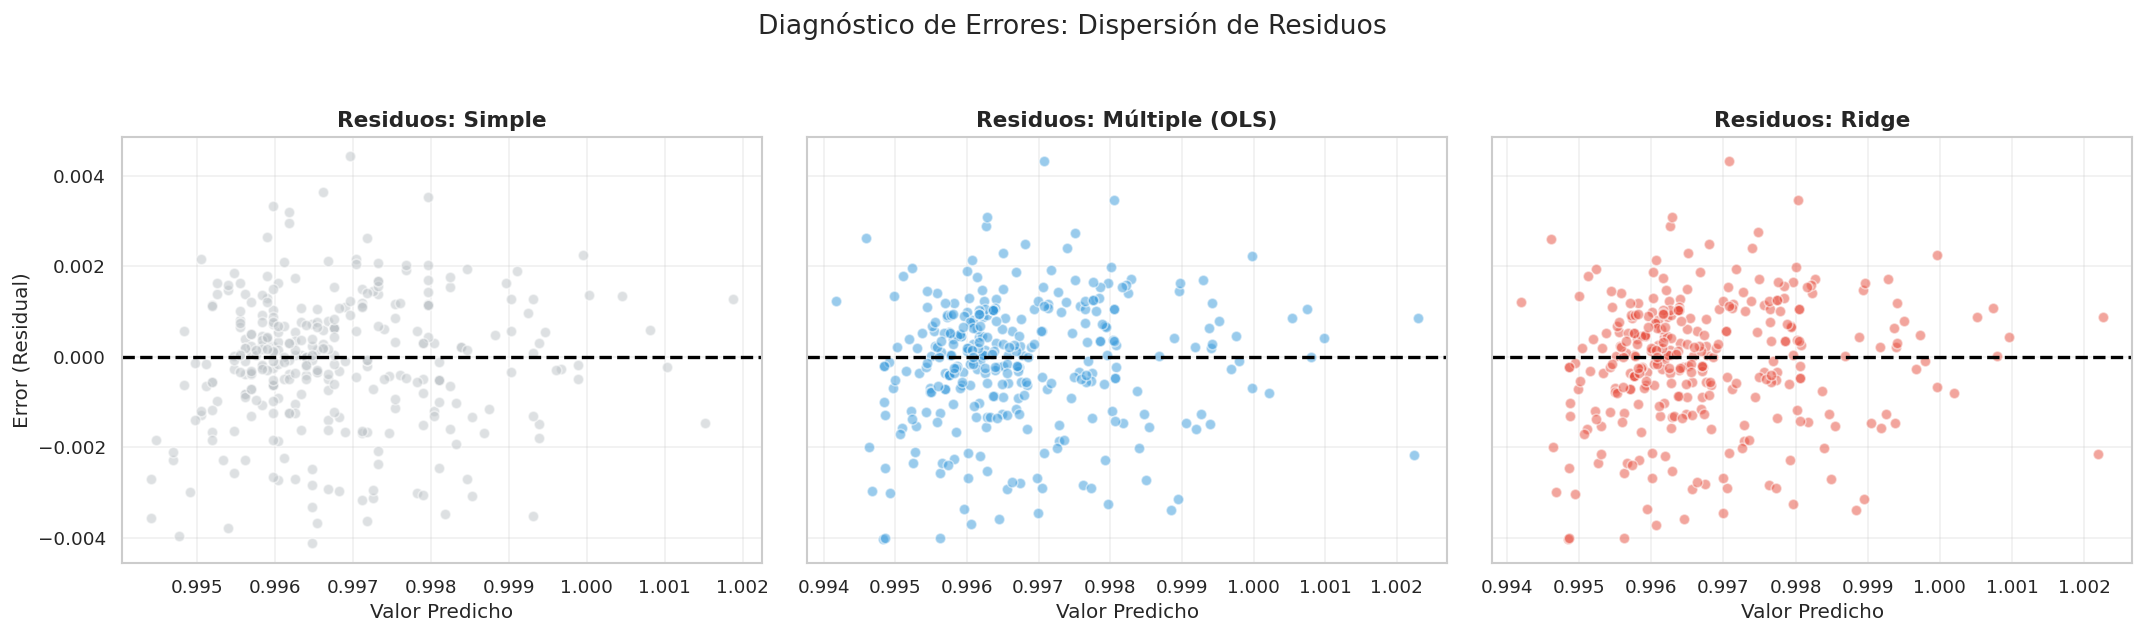

In [29]:
# ── CELDA 24: Gráfico de Residuos vs. Predichos (Comparativa) ──────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

modelos_eval = [
    ('Simple', y_pred_simple, y_test, '#bdc3c7'),
    ('Múltiple (OLS)', y_pred_multi, y_test_m, '#3498db'),
    ('Ridge', y_pred_ridge, y_test_m, '#e74c3c')
]

for i, (nombre, pred, real, color) in enumerate(modelos_eval):
    # Calculamos residuo
    residuos = real - pred
    
    # Graficamos
    axes[i].scatter(pred, residuos, alpha=0.5, c=color, edgecolors='white', s=40)
    
    # Línea de error Cero
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=2)
    
    axes[i].set_title(f'Residuos: {nombre}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Valor Predicho')
    if i == 0: axes[i].set_ylabel('Error (Residual)')
    axes[i].grid(alpha=0.3)

plt.suptitle('Diagnóstico de Errores: Dispersión de Residuos', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()